# Sheet 5

In [1]:
import os
import pandas as pd

## 2 Logistic regression: an LLM lie detector

Download the data from https://heibox.uni-heidelberg.de/f/38bd3f2a9b7944248cc2/   
Unzip it and place the lie_detection folder in the folder named `data` to get the following structure:
"data/lie_detection/datasets" and "data/lie_detection/acts".

This is how you can load a dataset of LLM activations. Use a new Datamanager if you want to have a new dataset. Use the same data manager if you want to combine datasets.

In [ ]:
from lie_detection_utils import DataManager

path_to_datasets = "data/lie_detection/datasets"
path_to_acts = "data/lie_detection/acts"

# check if the datasets and activations are available
assert os.path.exists(path_to_datasets), "The path to the datasets does not exist."
assert os.path.exists(path_to_acts), "The path to the activations does not exist."

# these are the different datasets containing true and false factual statements about different topics
dataset_names = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans"]
dataset_name = dataset_names[0] # choose some dataset from the above datasets, index "0" loads the "cities" dataset for example

# the dataloader automatically loads the training data for us
dm = DataManager()
dm.add_dataset(dataset_name, "Llama3", "8B", "chat", layer=12, split=0.8, center=False,
                device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
acts_train, labels_train = dm.get('train') # train set
acts_test, labels_test = dm.get('val')
print(acts_train.shape, labels_train.shape)

In [ ]:
# have a look at the statements that were fed to the LLM to produce the activations:
df = pd.read_csv(f"{path_to_datasets}/{dataset_name}.csv")
print(df.head(10))

## 3 Log-sum-exp and soft(arg)max
### (b)

### (c)

## 4 Linear regions of MLPs



- The goal of this exercise is to build and investigate the behavior of Multi-Layer Perceptrons (MLPs) 
- with ReLU activations in terms of the number of linear regions they create in the input space.
- We will implement two models using PyTorch: one shallow model with a single hidden layer and another deeper model.
- We will visualize the output of these MLPs and examine their gradient behavior over a 2D input space.


Part (a)

In [1]:
import torch
import torch.nn as nn

# Define the shallow model
class ShallowMLP(nn.Module):
    def __init__(self):
        super(ShallowMLP, self).__init__()
        self.hidden = nn.Linear(2, 20)  # 2 input features and 20 neurons in hidden layer
        self.output = nn.Linear(20, 1)  # Output is a scalar value

    def forward(self, x):
        x = torch.relu(self.hidden(x))  # ReLU activation on hidden layer
        x = self.output(x)  # No activation on output layer
        return x

# Instantiate the model
model = ShallowMLP()

# Calculate the number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The number of parameters in the model: {num_params}')


The number of parameters in the model: 81


Part (b)

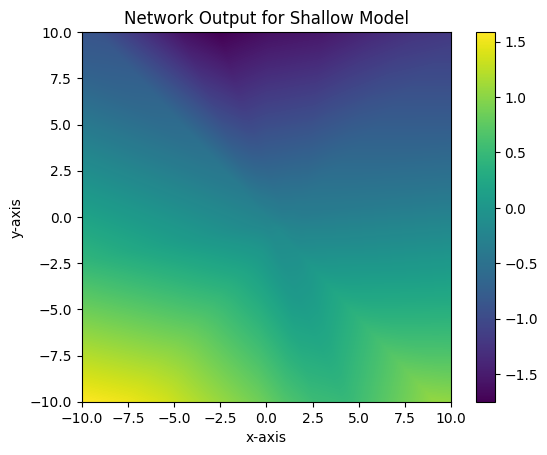

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of points in the range [-10, 10] x [-10, 10]
x_range = np.linspace(-10, 10, 500)
y_range = np.linspace(-10, 10, 500)
xx, yy = np.meshgrid(x_range, y_range)
grid = np.c_[xx.ravel(), yy.ravel()]

# Convert grid to a tensor
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Pass grid through the model
with torch.no_grad():
    z = model(grid_tensor).numpy()

# Reshape the output to match the grid shape
z = z.reshape(xx.shape)

# Plot the output as an image
plt.imshow(z, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Network Output for Shallow Model")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


Part (C)

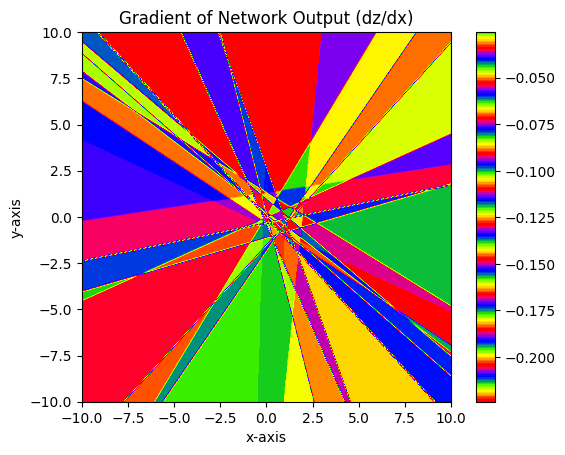

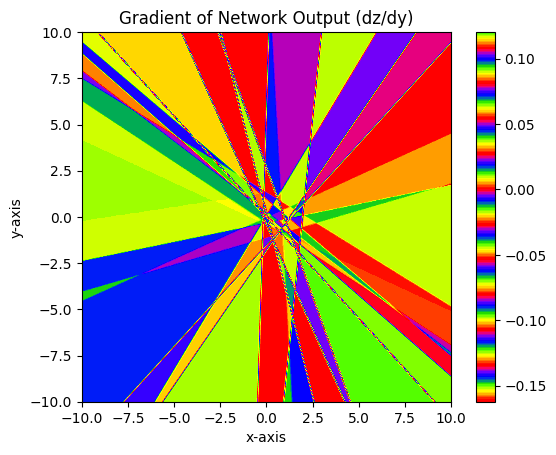

In [3]:
# Compute the gradient using numpy's gradient function
dz_dx, dz_dy = np.gradient(z, x_range, y_range)

# Plot the gradient components
plt.imshow(dz_dx, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

plt.imshow(dz_dy, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


Part (d)

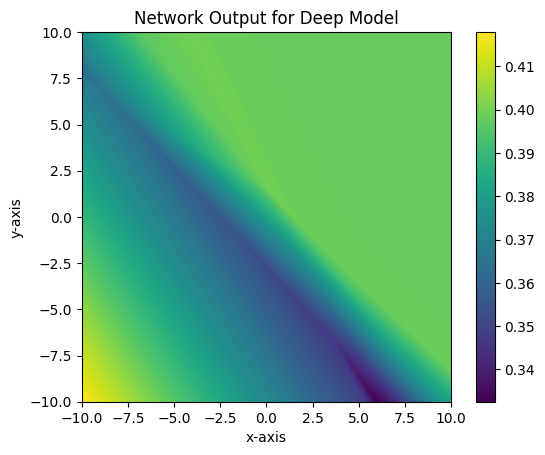

In [4]:
# Define the deeper model
class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()
        self.layer1 = nn.Linear(2, 5)
        self.layer2 = nn.Linear(5, 5)
        self.layer3 = nn.Linear(5, 5)
        self.layer4 = nn.Linear(5, 5)
        self.output = nn.Linear(5, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = torch.relu(self.layer4(x))
        x = self.output(x)
        return x

# Instantiate the model
deep_model = DeepMLP()

# Pass the grid through the deep model and visualize (similar to part b)
with torch.no_grad():
    z_deep = deep_model(grid_tensor).numpy()

# Reshape the output to match the grid shape
z_deep = z_deep.reshape(xx.shape)

# Plot the output as an image
plt.imshow(z_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Network Output for Deep Model")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()
